In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.optimize import curve_fit

from file_reading import pd_read_exp_file
import lorentz_fit as lorentz
import plotting

## **Experiment B**

In [2]:
lowest_harmonic = 274.25448868690813

{'trials': 20, 'sleeptime': 0.9, 'target_temp': 60.0, 'current_temp': 47.29185250200002, 'current_temp_err': 0.008335831867230336}


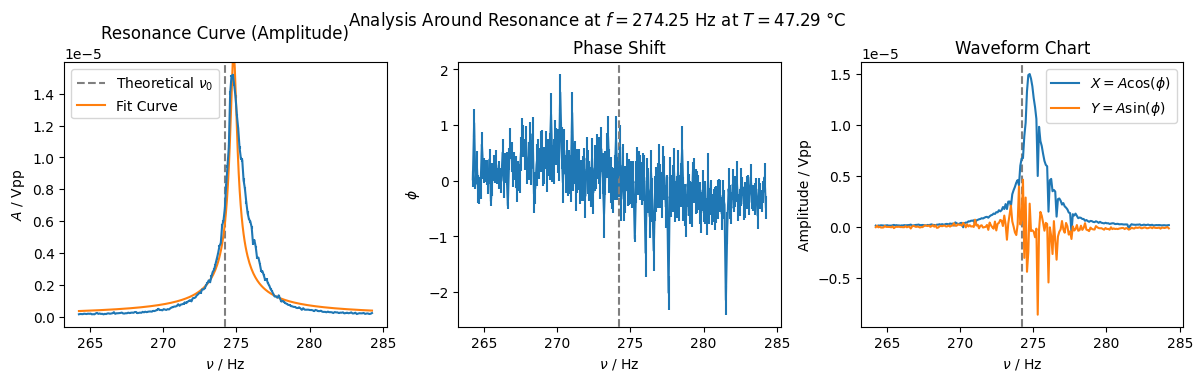

{'trials': 20, 'sleeptime': 0.9, 'target_temp': 56.66666666666667, 'current_temp': 63.436495770000064, 'current_temp_err': 1.4210854715202004e-16}


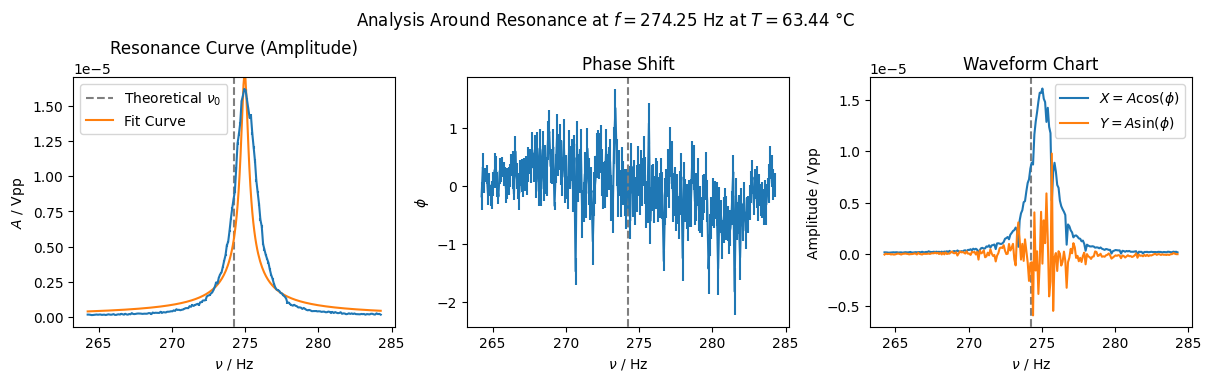

{'trials': 20, 'sleeptime': 0.9, 'target_temp': 53.333333333333336, 'current_temp': 62.05200251400002, 'current_temp_err': 0.001947794297862154}


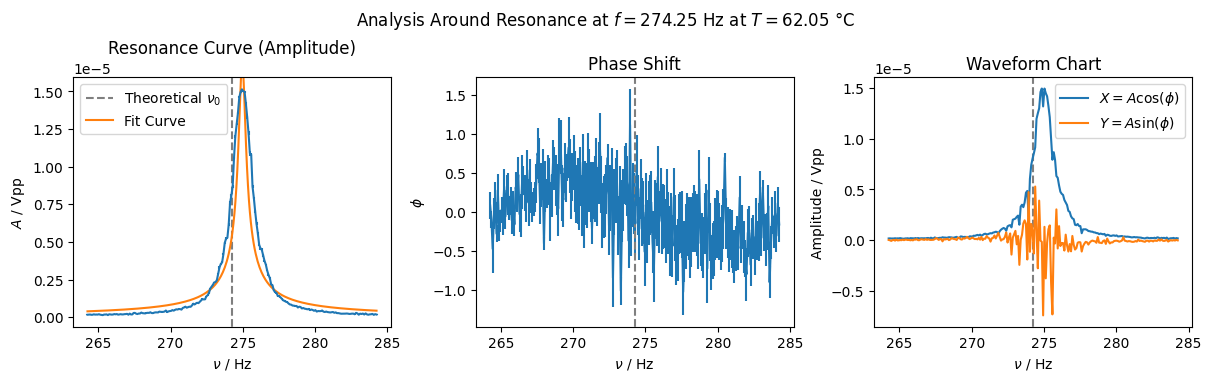

{'trials': 20, 'sleeptime': 0.9, 'target_temp': 50.0, 'current_temp': 62.010519570000014, 'current_temp_err': 0.0022453302079854525}


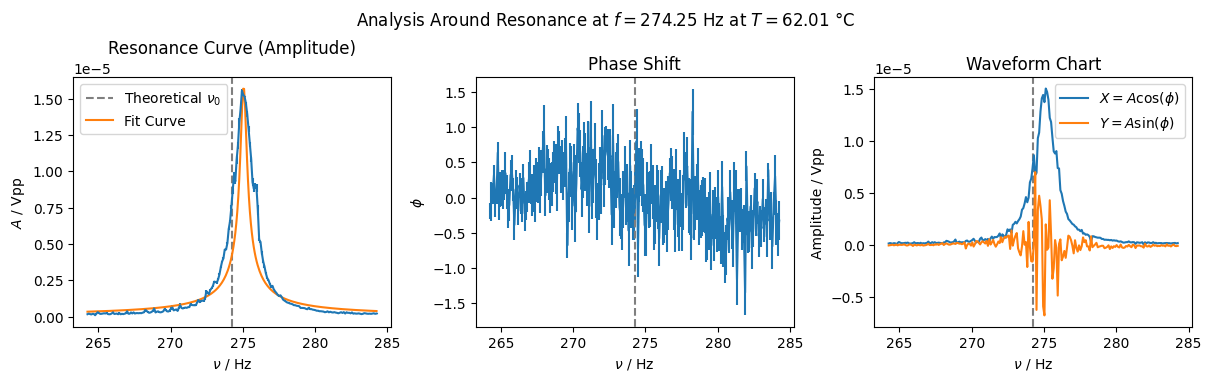

{'trials': 20, 'sleeptime': 0.9, 'target_temp': 46.66666666666667, 'current_temp': 61.642358442, 'current_temp_err': 0.0010161204582844893}


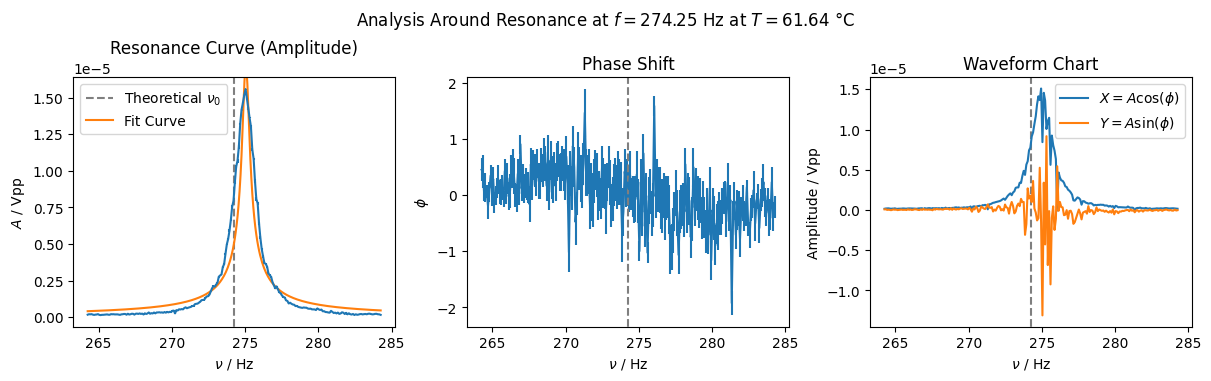

{'trials': 20, 'sleeptime': 0.9, 'target_temp': 43.333333333333336, 'current_temp': 61.36494125400002, 'current_temp_err': 0.0036573389702678886}


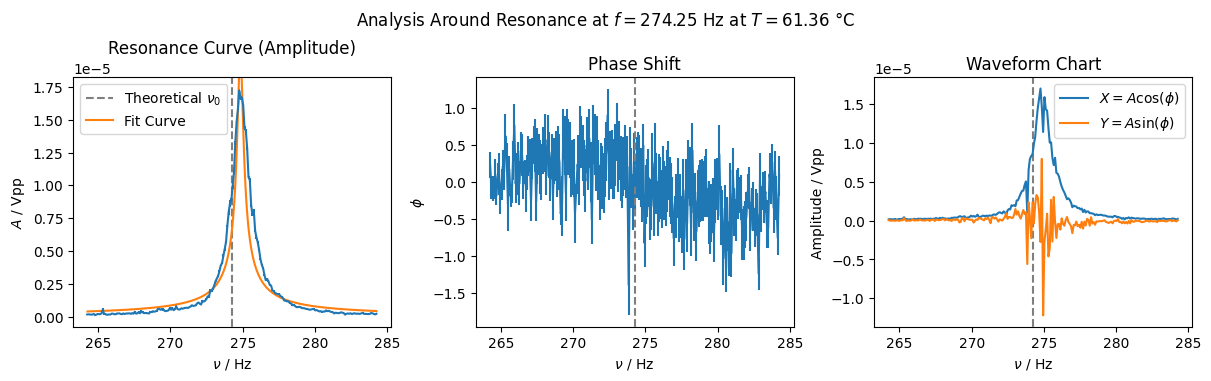

{'trials': 20, 'sleeptime': 0.9, 'target_temp': 40.0, 'current_temp': 61.06937527800002, 'current_temp_err': 0.0035293848374945936}


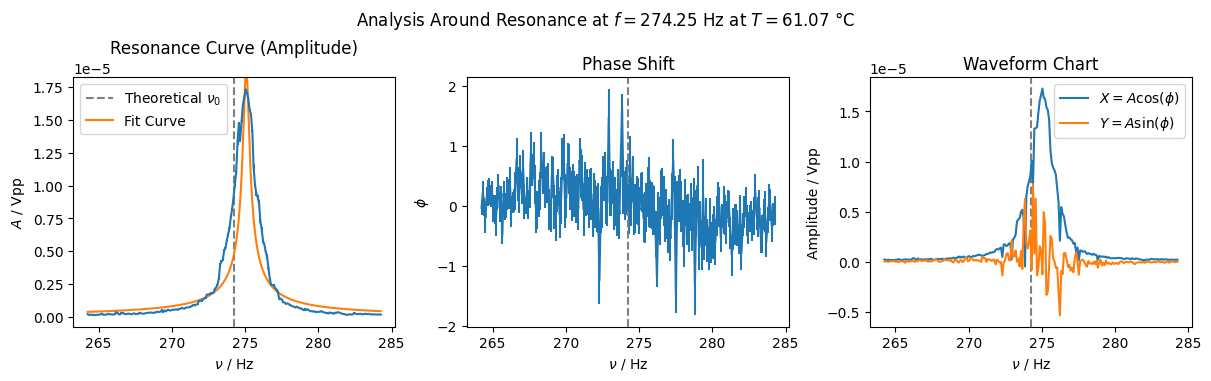

{'trials': 20, 'sleeptime': 0.9, 'target_temp': 33.333333333333336, 'current_temp': 63.41575429800007, 'current_temp_err': 0.0010161204582844893}


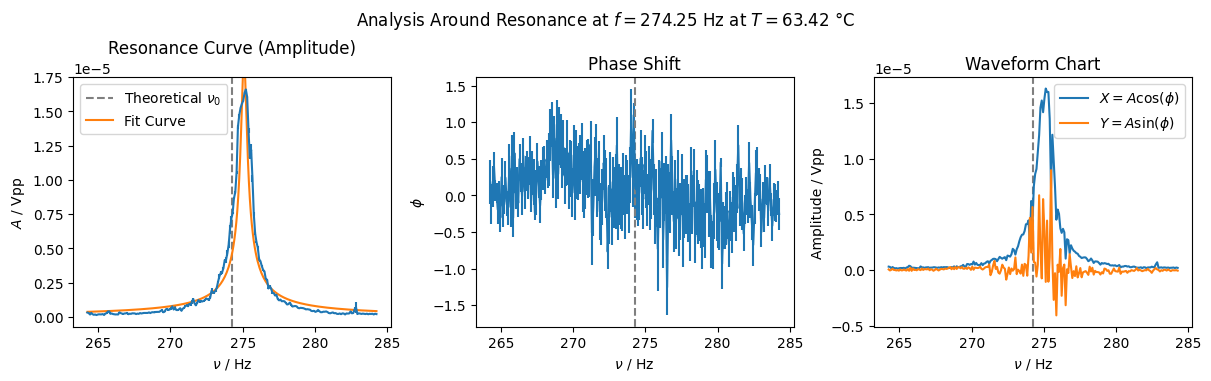

{'trials': 20, 'sleeptime': 0.9, 'target_temp': 36.666666666666664, 'current_temp': 62.964627282000045, 'current_temp_err': 0.0014839577426918945}


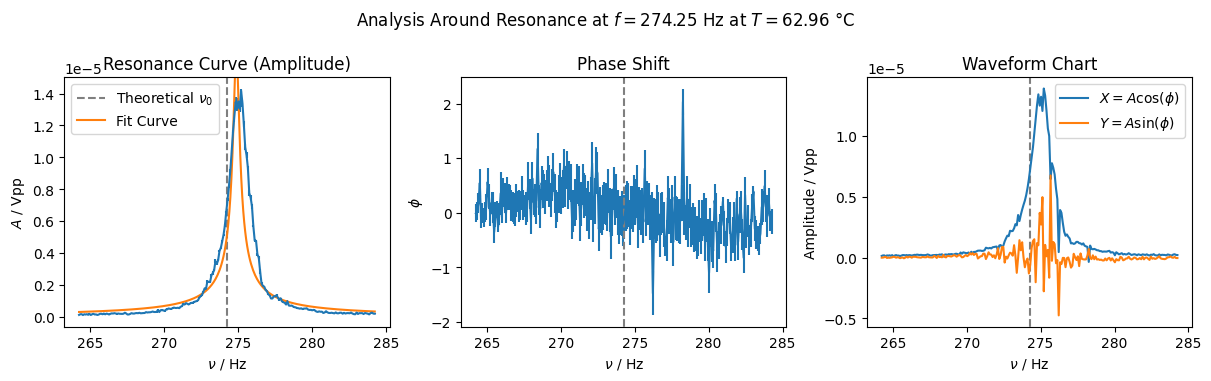

{'trials': 20, 'sleeptime': 0.9, 'target_temp': 30.0, 'current_temp': 64.73283777000002, 'current_temp_err': 0.0}


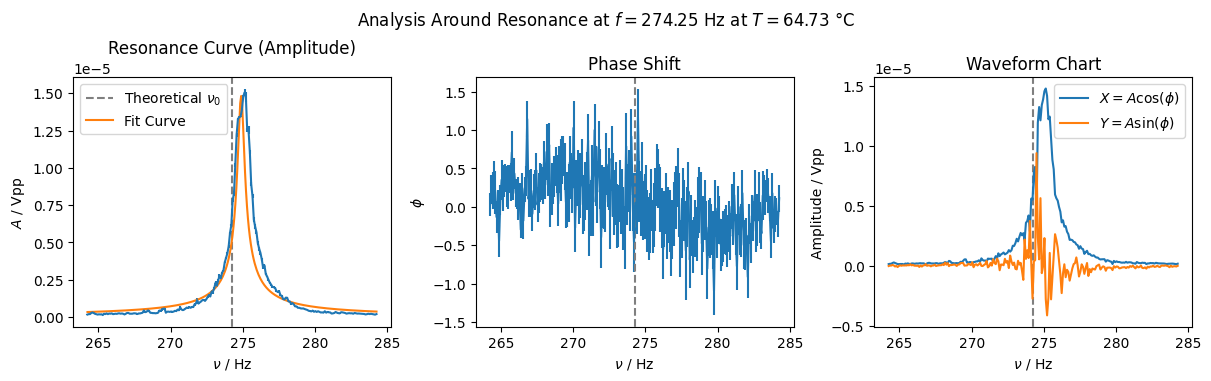

In [3]:
locs = [
    "temp0_data_0708_212553.txt",
    "temp1_data_0708_230411.txt",
    "temp2_data_0709_002229.txt",
    "temp3_data_0709_014047.txt",
    "temp4_data_0709_025905.txt",
    "temp5_data_0709_041723.txt",
    "temp6_data_0709_053541.txt",
    "temp8_data_0709_081217.txt",
    "temp7_data_0709_065359.txt",
    "temp9_data_0709_093035.txt",
]
path = "Data/Night Measurement/Experiment_B/"
locs = [path + loc for loc in locs]

fitparam_results: list[dict] = []

for i, loc in enumerate(locs):
    data, metadata = pd_read_exp_file(loc)
    print(metadata)
    temp = metadata["current_temp"]

    fig, axs = plt.subplots(1, 3, figsize=(4*3, 3.7), constrained_layout=True)
    plotting.pd_freq_spectrum(fig, axs, data)
    for ax in axs:
        plotting.vertical_line(ax, lowest_harmonic, label=r"Theoretical $\nu_0$")

    # result_dict = {"current_temp": metadata["current_temp"], 'target_freq': lowest_harmonic, "target_voltage": metadata["target_voltage"]}
    result_dict = {"current_temp": metadata["current_temp"], 'target_freq': lowest_harmonic}
    result_dict = result_dict | lorentz.do_fit(axs[0], data["freq"], data["A"], data["A_err"])
    fitparam_results.append(result_dict)

    axs[0].legend()
    fig.suptitle(f"Analysis Around Resonance at $ f = {lowest_harmonic:.2f}$ Hz at $ T = {temp:.2f} $ °C")
    plt.show()

In [4]:
df = pd.DataFrame(fitparam_results)
df.pop('params_list')
df.pop('params_err_list')

display(df)

,current_temp,target_freq,f_0,f_0_err,omega_0,omega_0_err,gamma,gamma_err,fit_Q_factor,fit_Q_err
0,47.291853,274.254489,0.080829,0.000183,1726.691186,0.006447,2.825469,0.009898,611.116570,1.636845e+08
1,63.436496,274.254489,0.093527,0.000193,1727.683629,0.006189,3.125756,0.008758,552.725056,1.542866e+08
2,62.052003,274.254489,0.088103,0.000183,1727.638467,0.006318,-2.998973,0.009868,-576.076697,-1.575267e+08
3,62.010520,274.254489,0.076784,0.000216,1728.232298,0.010704,2.802385,0.010320,616.700616,9.956827e+07
4,61.642358,274.254489,0.092484,0.000177,1728.206309,0.005028,-3.096715,0.009062,-558.077289,-1.918080e+08
5,61.364941,274.254489,0.088005,0.000215,1726.837012,0.006438,2.534421,0.012291,681.353760,1.827491e+08
6,61.069375,274.254489,0.089515,0.000204,1728.350906,0.005853,-2.733778,0.009019,-632.220652,-1.866825e+08
7,63.415754,274.254489,0.085477,0.000217,1728.417386,0.006108,-2.632809,0.010989,-656.491814,-1.857686e+08
8,62.964627,274.254489,0.073612,0.000202,1727.200924,0.011722,-2.551068,0.020152,-677.050049,-9.976178e+07
9,64.732838,274.254489,0.075902,0.000219,1727.157602,0.009720,2.964682,0.012118,582.577616,1.035173e+08


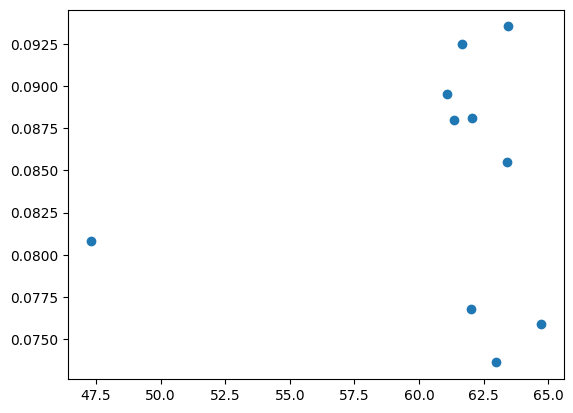

In [13]:
plt.scatter(df["current_temp"], df["f_0"])
plt.show()

In [ ]:
def find_maxima(data):
    i = np.argmax(data["A"])
    return data["freq"][i], data["A"][i], data["A_err"][i]

freqs = []
temps = []
for i, loc in enumerate(locs):
    data, metadata = pd_read_exp_file(loc)
    
    freq, A, A_err = find_maxima(data)
    freqs.append(freq)
    temps.append(metadata["current_temp"])


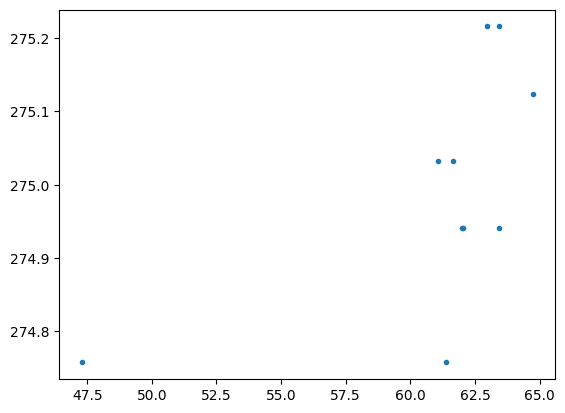

In [12]:
plt.scatter(temps, freqs, marker=".")
plt.show()

In [8]:
current_temps = []
target_voltage = []
for loc in locs:
    data, metadata = read_exp_file(loc)
    current_temps.append(metadata["current_temp"])
    target_voltage.append(calc_voltage_for_temp(metadata["target_temp"]))
    
    calc_voltage_for_temp(metadata["target_temp"])

plt.plot(target_voltage, current_temps, marker=".")

NameError: name 'read_exp_file' is not defined

In [ ]:
from Code.device_managers import illegal_calc_voltage_for_temp, calc_temp_for_voltage



In [ ]:
# fit functions for spectra
# calc chi square and p value
# plot residuals
# güte des resonators

# part b
# fit each spectrum (g.o.f.)
# resonance frequencies against temp plot
# linear regression fit
# slope = temp coeff
# vorzeichen der steigung

